Best-fit effective low-energy weight f_low = 0.000
Best-fit constant K (u_true) = 124094.4 cps·cm^2


/var/folders/gx/w2rl980s5h17rg173b0sxmy00000gn/T/ipykernel_26388/1899770123.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda s: pd.Series(wmean(s["u_cps_cm2"].values, s["sigma_u_cps_cm2"].values),
/var/folders/gx/w2rl980s5h17rg173b0sxmy00000gn/T/ipykernel_26388/1899770123.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(s, E)
/var/folders/gx/w2rl980s5h17rg173b0sxmy00000gn/T/ipykernel_26388/1899770123.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  surv = np.trapz(s[mask], E[mas

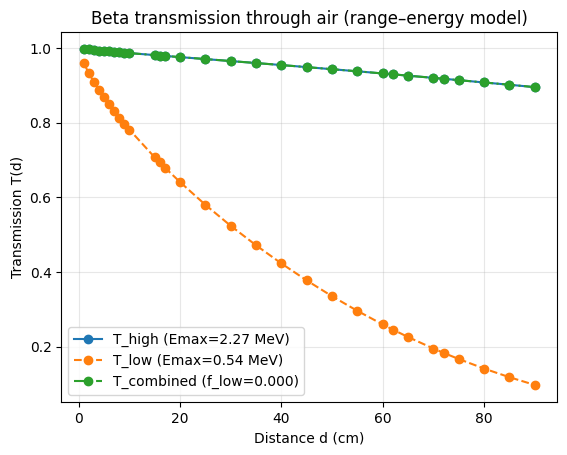

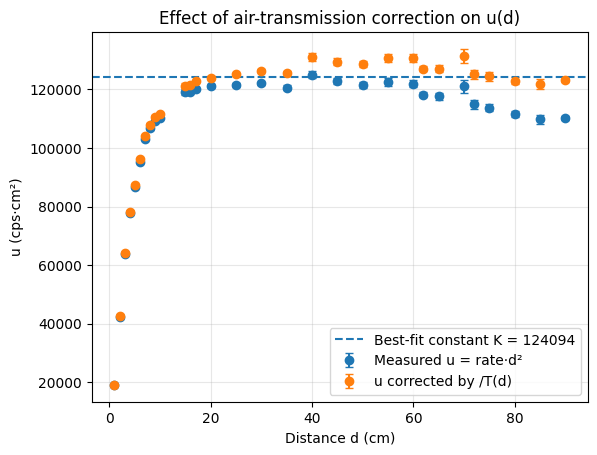

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Load your processed dataset
# ---------------------------
path = "data/filtered_data.csv"
df = pd.read_csv(path)

# ---------------------------------------------
# Collapse repeats: weighted mean of u per dist
# ---------------------------------------------
g = df.dropna(subset=["distance_cm", "u_cps_cm2", "sigma_u_cps_cm2"]).copy()

def wmean(vals, sig):
    w = 1.0 / (sig**2)
    return np.sum(w * vals) / np.sum(w), np.sqrt(1.0 / np.sum(w))

by_d = (
    g.groupby("distance_cm")
     .apply(lambda s: pd.Series(wmean(s["u_cps_cm2"].values, s["sigma_u_cps_cm2"].values),
                                index=["u", "su"]))
     .reset_index()
     .sort_values("distance_cm")
)

# --------------------------
# Physics: range -> Emin(d)
# --------------------------
me = 0.511  # electron rest mass energy [MeV]

def E_from_R(R):
    # Invert R = 0.11*(sqrt(1+22.4 E^2)-1)
    R = np.asarray(R, dtype=float)
    val = ((1 + R/0.11)**2 - 1) / 22.4
    val = np.maximum(val, 0.0)
    return np.sqrt(val)

def spectrum_allowed(E, E0):
    # Unnormalised allowed beta spectrum (ignore Fermi function)
    # N(E) ∝ p * W * (E0 - E)^2, with W=E+me, p=sqrt(W^2-me^2)
    E = np.asarray(E)
    W = E + me
    p = np.sqrt(np.maximum(W**2 - me**2, 0.0))
    return p * W * (E0 - E)**2 * (E >= 0) * (E <= E0)

def survival_fraction(E0, Ecut, n=6000):
    # fraction of spectrum above Ecut
    if Ecut <= 0:
        return 1.0
    if Ecut >= E0:
        return 0.0
    E = np.linspace(0.0, E0, n)
    s = spectrum_allowed(E, E0)
    total = np.trapz(s, E)
    mask = E >= Ecut
    surv = np.trapz(s[mask], E[mask])
    return float(surv / total) if total > 0 else 0.0

# --------------------------------------------
# Inputs: air density and Sr-90 beta endpoints
# --------------------------------------------
rho_air = 0.001204  # g/cm^3  (≈1.204 kg/m^3 at ~20°C, 1 atm)
Emax_low, Emax_high = 0.54, 2.27  # MeV

d = by_d["distance_cm"].values
sigma_air = rho_air * d            # g/cm^2
Ecut_air = E_from_R(sigma_air)     # Emin(d) in MeV

# Precompute T_low(d) and T_high(d)
T_low  = np.array([survival_fraction(Emax_low,  ec) for ec in Ecut_air])
T_high = np.array([survival_fraction(Emax_high, ec) for ec in Ecut_air])

# -----------------------------------------
# Fit f_low using far-field u(d) ≈ K * T(d)
# -----------------------------------------
dist = by_d["distance_cm"].values
u = by_d["u"].values
su = by_d["su"].values

fit_mask = dist >= 15   # <-- edit your far-field fit region here
u_fit, su_fit = u[fit_mask], su[fit_mask]
Tlow_fit, Thigh_fit = T_low[fit_mask], T_high[fit_mask]

f_grid = np.linspace(0, 1, 501)
w = 1.0 / (su_fit**2)

best_chi2 = np.inf
best_f = None
best_K = None

for f in f_grid:
    T = f * Tlow_fit + (1 - f) * Thigh_fit
    K = np.sum(w * u_fit * T) / np.sum(w * T**2)
    chi2 = np.sum(w * (u_fit - K*T)**2)
    if chi2 < best_chi2:
        best_chi2, best_f, best_K = chi2, f, K

T_combined = best_f * T_low + (1 - best_f) * T_high

# -----------------------------
# Apply correction: u_corr = u/T
# -----------------------------
u_corr = u / T_combined
su_corr = su / T_combined

print(f"Best-fit effective low-energy weight f_low = {best_f:.3f}")
print(f"Best-fit constant K (u_true) = {best_K:.1f} cps·cm^2")

# -------------------
# Plot transmission T
# -------------------
plt.figure()
plt.plot(d, T_high, marker="o", linestyle="-",  label="T_high (Emax=2.27 MeV)")
plt.plot(d, T_low,  marker="o", linestyle="--", label="T_low (Emax=0.54 MeV)")
plt.plot(d, T_combined, marker="o", linestyle="-.", label=f"T_combined (f_low={best_f:.3f})")
plt.xlabel("Distance d (cm)")
plt.ylabel("Transmission T(d)")
plt.title("Beta transmission through air (range–energy model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# Plot u(d) before/after correction
# -----------------------------
plt.figure()
plt.errorbar(dist, u, yerr=su, fmt="o", capsize=3, label="Measured u = rate·d²")
plt.errorbar(dist, u_corr, yerr=su_corr, fmt="o", capsize=3, label="u corrected by /T(d)")
plt.axhline(best_K, linestyle="--", label=f"Best-fit constant K = {best_K:.0f}")
plt.xlabel("Distance d (cm)")
plt.ylabel("u (cps·cm²)")
plt.title("Effect of air-transmission correction on u(d)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
